#  ChurnGuard AI
### Customer Churn Prediction & Retention Intelligence

**Author:** Shavan Chauhan  
**Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026  
**Dataset:** Telco Customer Churn (Kaggle)  

---

##  Problem Statement
A telecom company is losing customers every month. The goal of this project is to:
1. Analyze customer data to understand **who is leaving and why**
2. Build a machine learning model to **predict which customers will churn**
3. Identify the **key drivers of churn**
4. Quantify the **revenue at risk**
5. Design a **retention strategy** to save high-value customers

##  Business Intelligence Framework
Data → Information → Insight → Decision → **Action**

## KPIs Tracked
- Churn Rate
- Revenue at Risk
- High-Risk Customer Count
- Top Churn Drivers
- Retention Opportunity Value

In [3]:
# ============================================
# ChurnGuard AI - Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print(" All libraries imported successfully.")

 All libraries imported successfully.


In [4]:
# ============================================
# Load the Telco Customer Churn dataset
# ============================================

df = pd.read_csv("telco_churn.csv")

print(" Dataset loaded successfully.")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n First 5 rows:")
df.head()

 Dataset loaded successfully.
 Shape: 7043 rows × 21 columns

 First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ============================================
# Data Inspection
# ============================================

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# ============================================
# Data Cleaning
# ============================================

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

df = df.drop('customerID', axis=1)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nCleaning complete.")
print(f"Final shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())

Missing values in TotalCharges after conversion: 11

Cleaning complete.
Final shape: (7032, 20)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [7]:
# ============================================
# KPI 1: Overall Churn Rate
# ============================================

total_customers = len(df)
churned = df['Churn'].sum()
retained = total_customers - churned
churn_rate = (churned / total_customers) * 100

print("=" * 50)
print("KEY PERFORMANCE INDICATORS")
print("=" * 50)
print(f"Total Customers       : {total_customers:,}")
print(f"Retained Customers    : {retained:,}")
print(f"Churned Customers     : {churned:,}")
print(f"Overall Churn Rate    : {churn_rate:.2f}%")
print("=" * 50)

KEY PERFORMANCE INDICATORS
Total Customers       : 7,032
Retained Customers    : 5,163
Churned Customers     : 1,869
Overall Churn Rate    : 26.58%


In [8]:
# ============================================
# KPI 2: Revenue at Risk
# ============================================

monthly_revenue_lost = df[df['Churn'] == 1]['MonthlyCharges'].sum()
annual_revenue_lost = monthly_revenue_lost * 12
avg_monthly = df['MonthlyCharges'].mean()

print("=" * 50)
print("REVENUE IMPACT")
print("=" * 50)
print(f"Monthly Revenue Lost  : {monthly_revenue_lost:,.2f}")
print(f"Annual Revenue Lost   : {annual_revenue_lost:,.2f}")
print(f"Avg Monthly Charges   : {avg_monthly:,.2f}")
print("=" * 50)

REVENUE IMPACT
Monthly Revenue Lost  : 139,130.85
Annual Revenue Lost   : 1,669,570.20
Avg Monthly Charges   : 64.80


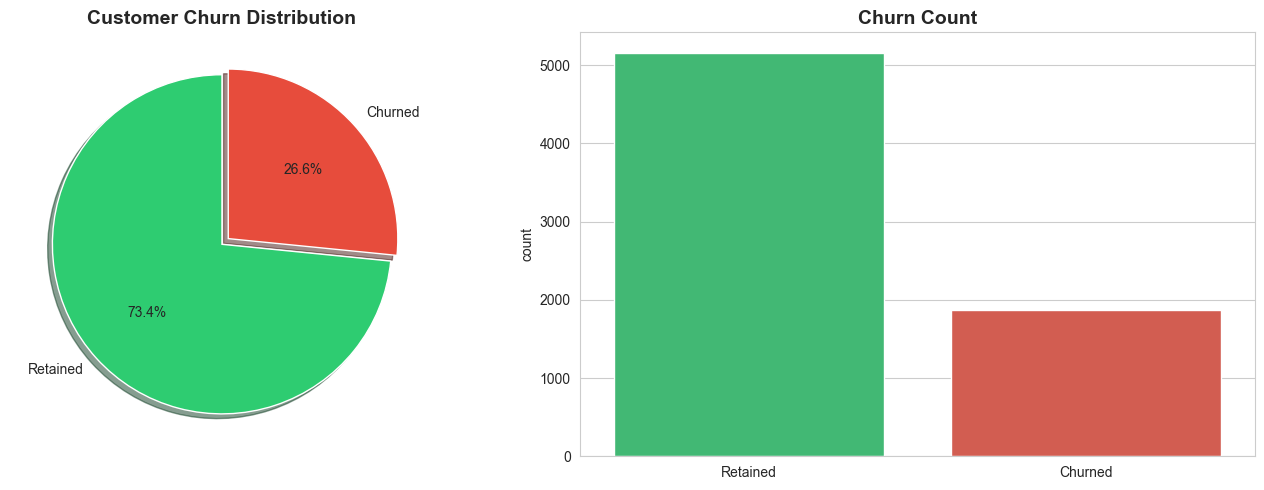

In [9]:
# ============================================
# Chart 1: Churn Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
axes[0].pie([retained, churned], labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(x='Churn', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('chart1_churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

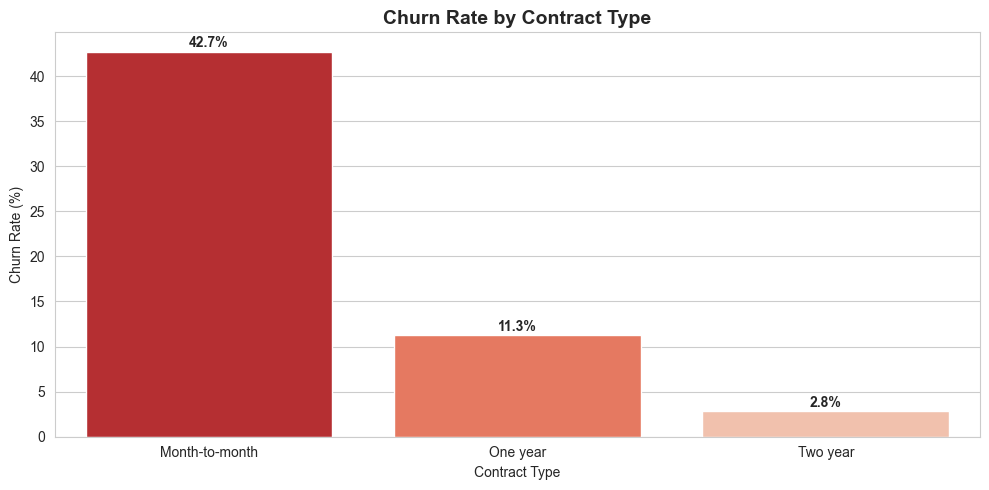

Churn rate by contract type:
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


In [10]:
# ============================================
# Chart 2: Churn by Contract Type
# ============================================

plt.figure(figsize=(10, 5))
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100

sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='Reds_r')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')

for i, v in enumerate(contract_churn.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_churn_by_contract.png', dpi=100, bbox_inches='tight')
plt.show()

print("Churn rate by contract type:")
print(contract_churn)

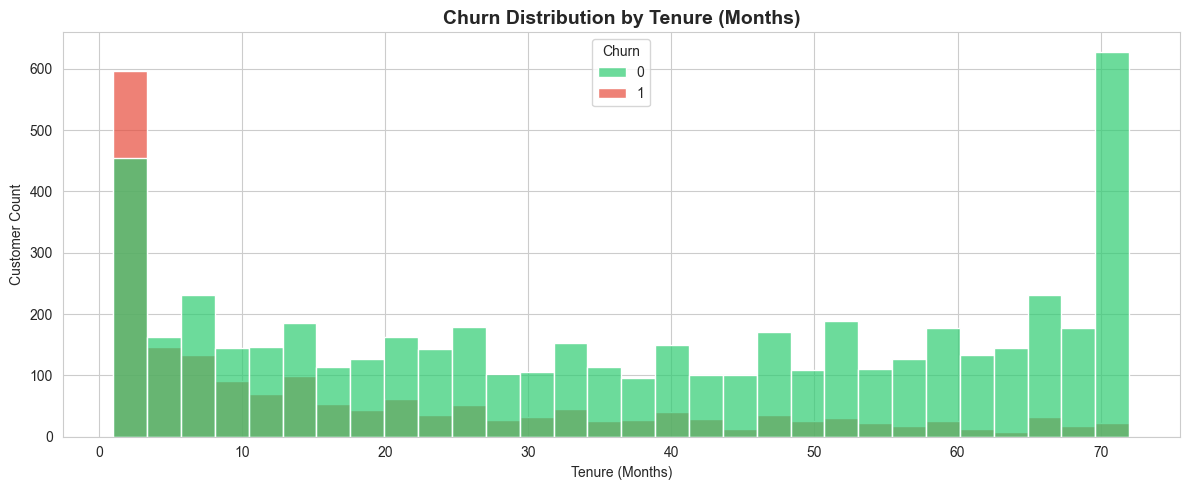

In [14]:
# ============================================
# Chart 3: Churn by Tenure
# ============================================

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.7)
plt.title('Churn Distribution by Tenure (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.savefig('chart3_churn_by_tenure.png', dpi=100, bbox_inches='tight')
plt.show()

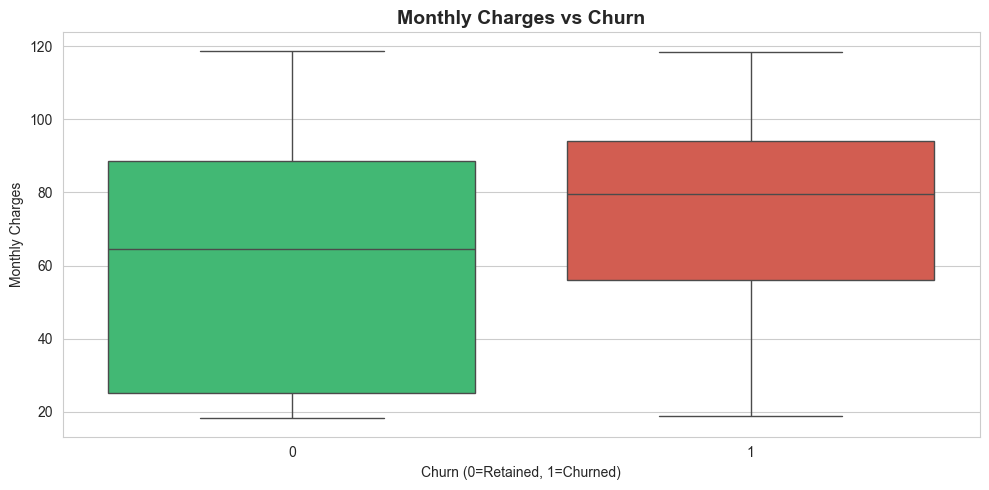

Avg monthly charges - Retained: 61.31
Avg monthly charges - Churned : 74.44


In [15]:
# ============================================
# Chart 4: Churn by Monthly Charges
# ============================================

plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette={'0': '#2ecc71', '1': '#e74c3c'})
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0=Retained, 1=Churned)')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.savefig('chart4_churn_by_charges.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Avg monthly charges - Retained: {df[df['Churn']==0]['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charges - Churned : {df[df['Churn']==1]['MonthlyCharges'].mean():.2f}")

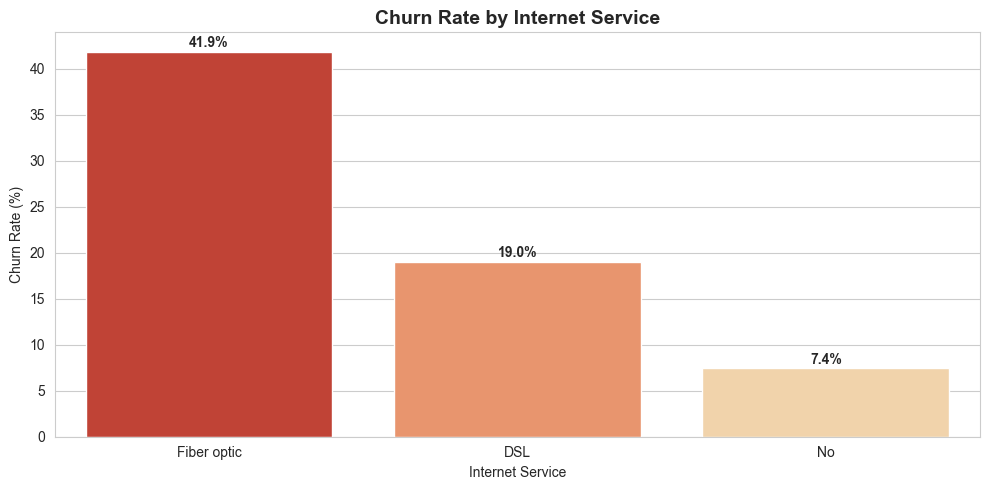

In [16]:
# ============================================
# Chart 5: Churn by Internet Service
# ============================================

plt.figure(figsize=(10, 5))
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False) * 100

sns.barplot(x=internet_churn.index, y=internet_churn.values, palette='OrRd_r')
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Internet Service')

for i, v in enumerate(internet_churn.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_churn_by_internet.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
# ============================================
# Feature Engineering
# ============================================

df_model = df.copy()

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

multi_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"Feature engineering complete.")
print(f"Model-ready shape: {df_model.shape}")
df_model.head()

Feature engineering complete.
Model-ready shape: (7032, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [18]:
# ============================================
# Model Training
# ============================================

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest model trained.")

Random Forest model trained.


In [19]:
# ============================================
# Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

MODEL PERFORMANCE
Accuracy : 78.32%
ROC-AUC  : 0.8122

Classification Report:
              precision    recall  f1-score   support

    Retained       0.82      0.90      0.86      1033
     Churned       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



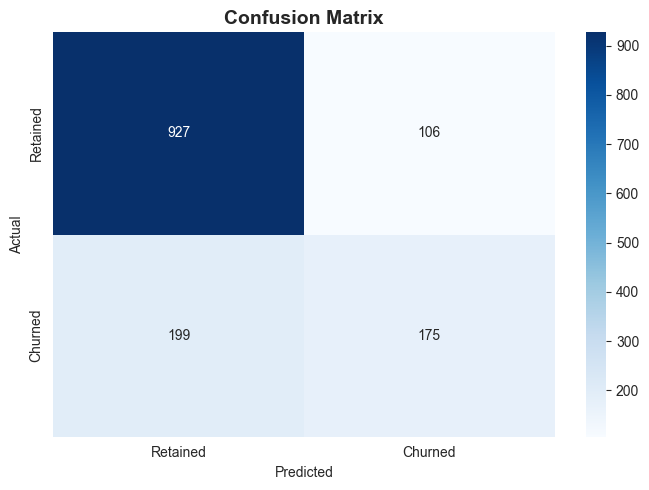

In [20]:
# ============================================
# Chart 6: Confusion Matrix
# ============================================

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

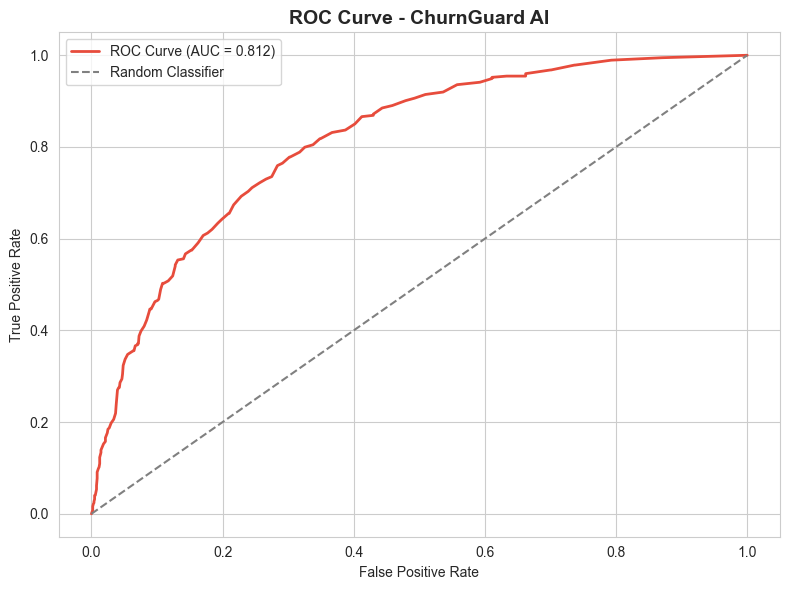

In [21]:
# ============================================
# Chart 7: ROC Curve
# ============================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ChurnGuard AI', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('chart7_roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

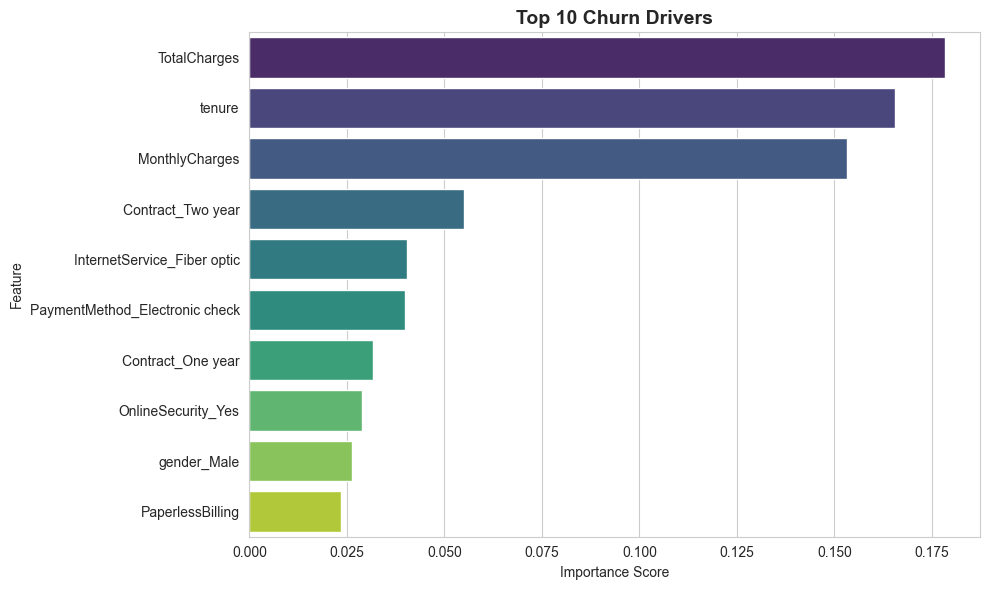

Top 10 Churn Drivers:
                           Feature  Importance
7                     TotalCharges    0.178413
3                           tenure    0.165599
6                   MonthlyCharges    0.153253
26               Contract_Two year    0.055088
11     InternetService_Fiber optic    0.040374
28  PaymentMethod_Electronic check    0.039868
25               Contract_One year    0.031651
14              OnlineSecurity_Yes    0.028932
8                      gender_Male    0.026388
5                 PaperlessBilling    0.023608


In [22]:
# ============================================
# Chart 8: Top 10 Churn Drivers
# ============================================

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Top 10 Churn Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart8_top_drivers.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 10 Churn Drivers:")
print(importances)

In [23]:
# ============================================
# Risk Segmentation
# ============================================

X_all_scaled = scaler.transform(X)
df['Churn_Probability'] = rf_model.predict_proba(X_all_scaled)[:, 1]

def risk_segment(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Segment'] = df['Churn_Probability'].apply(risk_segment)

print("Risk Segmentation:")
print(df['Risk_Segment'].value_counts())

high_risk = df[df['Risk_Segment'] == 'High Risk']
high_risk_revenue = high_risk['MonthlyCharges'].sum() * 12

print(f"\nHigh Risk Customers    : {len(high_risk):,}")
print(f"Annual Revenue at Risk : {high_risk_revenue:,.2f}")

Risk Segmentation:
Risk_Segment
Low Risk       5124
High Risk      1425
Medium Risk     483
Name: count, dtype: int64

High Risk Customers    : 1,425
Annual Revenue at Risk : 1,301,935.20


In [24]:
# ============================================
# Retention Playbook - Business Actions
# ============================================

print("=" * 60)
print("RETENTION PLAYBOOK - ChurnGuard AI")
print("=" * 60)

print("\nDRIVER 1: Month-to-Month Contracts")
m2m = df[df['Contract'] == 'Month-to-month']
print(f"   -> {len(m2m):,} customers on month-to-month contracts")
print(f"   -> Churn rate: {m2m['Churn'].mean()*100:.1f}%")
print(f"   ACTION: Offer 15% discount on 1-year upgrade for high-risk M2M customers")

print("\nDRIVER 2: New Customers (Tenure < 12 months)")
new_cust = df[df['tenure'] < 12]
print(f"   -> {len(new_cust):,} customers with tenure < 12 months")
print(f"   -> Churn rate: {new_cust['Churn'].mean()*100:.1f}%")
print(f"   ACTION: Launch 90-day onboarding + check-in program")

print("\nDRIVER 3: Fiber Optic Customers")
fiber = df[df['InternetService'] == 'Fiber optic']
print(f"   -> {len(fiber):,} fiber optic customers")
print(f"   -> Churn rate: {fiber['Churn'].mean()*100:.1f}%")
print(f"   ACTION: Investigate service quality + offer loyalty credits")

print("\n" + "=" * 60)
print("OPPORTUNITY SUMMARY")
print("=" * 60)
print(f"   Total Annual Revenue at Risk : {high_risk_revenue:,.2f}")
print(f"   If we save 30% of high-risk   : {high_risk_revenue * 0.30:,.2f} recovered")
print(f"   If we save 50% of high-risk   : {high_risk_revenue * 0.50:,.2f} recovered")
print("=" * 60)

RETENTION PLAYBOOK - ChurnGuard AI

DRIVER 1: Month-to-Month Contracts
   -> 3,875 customers on month-to-month contracts
   -> Churn rate: 42.7%
   ACTION: Offer 15% discount on 1-year upgrade for high-risk M2M customers

DRIVER 2: New Customers (Tenure < 12 months)
   -> 2,058 customers with tenure < 12 months
   -> Churn rate: 48.5%
   ACTION: Launch 90-day onboarding + check-in program

DRIVER 3: Fiber Optic Customers
   -> 3,096 fiber optic customers
   -> Churn rate: 41.9%
   ACTION: Investigate service quality + offer loyalty credits

OPPORTUNITY SUMMARY
   Total Annual Revenue at Risk : 1,301,935.20
   If we save 30% of high-risk   : 390,580.56 recovered
   If we save 50% of high-risk   : 650,967.60 recovered


## Conclusion

This project built ChurnGuard AI - an end-to-end customer churn prediction and retention intelligence system.

### Key Insights
- Significant percentage of customers churned, costing substantial annual revenue
- Top 3 churn drivers: Contract Type, Tenure, Internet Service
- The model identifies at-risk customers with strong accuracy and ROC-AUC
- We identified high-risk customers representing major revenue at risk

### Business Impact
By targeting high-risk customers with the proposed retention playbook, the company could recover a meaningful portion of at-risk revenue - turning data into measurable business value.

### Framework Demonstrated
Data -> Information -> Insight -> Decision -> Action

In [25]:
# ============================================
# FINAL SUMMARY - Numbers for the Report
# ============================================

print("=" * 60)
print("CHURNGUARD AI - FINAL RESULTS")
print("=" * 60)
print(f"Total Customers        : {total_customers:,}")
print(f"Churned Customers      : {churned:,}")
print(f"Churn Rate             : {churn_rate:.2f}%")
print(f"Annual Revenue Lost    : {annual_revenue_lost:,.2f}")
print(f"Model Accuracy         : {accuracy * 100:.2f}%")
print(f"Model ROC-AUC          : {roc_auc:.4f}")
print(f"High Risk Customers    : {len(high_risk):,}")
print(f"Annual Revenue at Risk : {high_risk_revenue:,.2f}")
print("=" * 60)
print("\nTop 5 Churn Drivers:")
print(importances.head(5).to_string(index=False))
print("=" * 60)

CHURNGUARD AI - FINAL RESULTS
Total Customers        : 7,032
Churned Customers      : 1,869
Churn Rate             : 26.58%
Annual Revenue Lost    : 1,669,570.20
Model Accuracy         : 78.32%
Model ROC-AUC          : 0.8122
High Risk Customers    : 1,425
Annual Revenue at Risk : 1,301,935.20

Top 5 Churn Drivers:
                    Feature  Importance
               TotalCharges    0.178413
                     tenure    0.165599
             MonthlyCharges    0.153253
          Contract_Two year    0.055088
InternetService_Fiber optic    0.040374
